In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
path = "/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET"

In [ ]:
files = os.listdir("/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion")
print(files)

['utils.py', 'Readme file - Description of Experimental Tests.txt', 'Technical Information and Experimental Test Results for LG 18650HG2.pdf', '10degC', '0degC', '25degC', '40degC', 'n10degC', 'n20degC', 'Day_8_Data_Quality_Reports']


In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [ ]:
 csv_files = []
for root, dirs, files in os.walk("/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion"):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))
csv_files = sorted(csv_files)
print("\nNumber of CSV files found:", len(csv_files))
if len(csv_files) == 0:
    raise FileNotFoundError("No CSV files were found. Check that your dataset has been uploaded ""or mounted in Google Drive.")
for i, file_path in enumerate(csv_files, start=1):
    print(i, ":", file_path)


Number of CSV files found: 208
1 : /content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/0degC/585_C20DisCh.csv
2 : /content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/0degC/585_Dis_0p5C.csv
3 : /content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/0degC/585_Dis_2C.csv
4 : /content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/0degC/585_HPPC.csv
5 : /content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/0degC/589_Cap_1C.csv
6 : /content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/0degC/589_Charge1.csv
7 : /content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/0degC/589_Charge2.csv
8 : /content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/0degC/589_Charge3.csv
9 : /content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/0degC/589_Charge4.csv
10 : /content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/0degC/589_Charge5.csv


In [ ]:
dataframes = []
failed_files = []
print("READING ALL CSV FILES")
for i, file_path in enumerate(csv_files, start=1):
    try:
        df = pd.read_csv(file_path,on_bad_lines="skip")
        df = df.dropna(axis=0, how="all")
        df = df.dropna(axis=1, how="all")
        df.columns = [str(col).strip().replace("\ufeff", "")
            for col in df.columns
        ]
        df["Source_File"] = os.path.basename(file_path)
        dataframes.append(df)
        print(f"FILE {i}/{len(csv_files)} | "f"{os.path.basename(file_path)} | "f"Rows: {len(df)} | "f"Columns: {len(df.columns)}")
    except Exception as e:
        failed_files.append((file_path, str(e)))
        print(f"FAILED {i}/{len(csv_files)} | "f"{os.path.basename(file_path)}")
        print("Reason:", e)
print("READING SUMMARY")
print("CSV files found :", len(csv_files))
print("Files read      :", len(dataframes))
print("Files failed    :", len(failed_files))
if len(failed_files) > 0:
    print("\nFAILED FILES:")
    for file_path, error in failed_files:
        print("\nFILE:", file_path)
        print("ERROR:", error)

READING ALL CSV FILES
FILE 1/208 | 585_C20DisCh.csv | Rows: 23 | Columns: 3
FILE 2/208 | 585_Dis_0p5C.csv | Rows: 23 | Columns: 3
FILE 3/208 | 585_Dis_2C.csv | Rows: 23 | Columns: 3
FILE 4/208 | 585_HPPC.csv | Rows: 23 | Columns: 3
FILE 5/208 | 589_Cap_1C.csv | Rows: 23 | Columns: 3
FILE 6/208 | 589_Charge1.csv | Rows: 23 | Columns: 3
FILE 7/208 | 589_Charge2.csv | Rows: 23 | Columns: 3
FILE 8/208 | 589_Charge3.csv | Rows: 23 | Columns: 3
FILE 9/208 | 589_Charge4.csv | Rows: 23 | Columns: 3
FILE 10/208 | 589_Charge5.csv | Rows: 23 | Columns: 3
FILE 11/208 | 589_Charge6.csv | Rows: 23 | Columns: 3
FILE 12/208 | 589_Charge7.csv | Rows: 23 | Columns: 3
FILE 13/208 | 589_Charge8.csv | Rows: 23 | Columns: 3
FILE 14/208 | 589_HWFET.csv | Rows: 23 | Columns: 3
FILE 15/208 | 589_LA92.csv | Rows: 23 | Columns: 3
FILE 16/208 | 589_Mixed1.csv | Rows: 23 | Columns: 3
FILE 17/208 | 589_Mixed2.csv | Rows: 23 | Columns: 3
FILE 18/208 | 589_UDDS.csv | Rows: 23 | Columns: 3
FILE 19/208 | 589_US06.csv |

In [ ]:
def find_header_row(file_path):
    """
    Find the row containing the actual measurement-table header.
    """
    try:
        raw = pd.read_csv(file_path,header=None,nrows=40,low_memory=False)
        possible_words = ['time','voltage','current','temperature','soc','capacity']
        for i in range(len(raw)):
            row_text = " ".join(str(x).lower() for x in raw.iloc[i].tolist())
            score = sum(word in row_text for word in possible_words)
            if score >= 2:
                return i
    except Exception:
        pass
    return None
def clean_battery_file(file_path):
    """
    Read one battery CSV file and remove metadata/non-measurement rows.
    """
    header_row = find_header_row(file_path)
    if header_row is None:
        return None
    try:
        df = pd.read_csv(file_path,header=header_row,low_memory=False)
        df = df.dropna(axis=1, how='all')
        df.columns = [str(col).strip()for col in df.columns]
        df = df.dropna(axis=0, how='all')
        df = df.loc[:, ~df.columns.duplicated()]
        df['Source_File'] = os.path.basename(file_path)
        return df
    except Exception:
        return None
cleaned_data = []
for file_path in csv_files:
    df = clean_battery_file(file_path)
    if df is not None and len(df) > 0:
        cleaned_data.append(df)
print("Successfully processed files:", len(cleaned_data))
if len(cleaned_data) == 0:
    raise ValueError("No measurement tables could be extracted from the CSV files.")
battery_df = pd.concat(cleaned_data,ignore_index=True,sort=False)
print("Combined dataset shape:", battery_df.shape)
print("\nColumns found:")
for col in battery_df.columns:
    print("-", col)

Successfully processed files: 1
Combined dataset shape: (858, 15)

Columns found:
- Time Stamp
- Step
- Status
- Prog Time
- Step Time
- Cycle
- Cycle Level
- Procedure
- Voltage
- Current
- Temperature
- Capacity
- WhAccu
- Cnt
- Source_File


In [ ]:
if len(dataframes) == 0:
    raise ValueError("None of the CSV files could be read.")
combined_df = pd.concat(dataframes,ignore_index=True,sort=False)
print("COMBINED DATASET")
print("Total rows:", len(combined_df))
print("Total columns:", len(combined_df.columns))
print("\nColumns:")
for col in combined_df.columns:
    print("-", col)

COMBINED DATASET
Total rows: 5643
Total columns: 37

Columns:
- Measurement ID
- 585
- Source_File
- 589
- 590
- 567
- 571
- 575
- 576
- 582
- 549
- Unnamed: 2
- Unnamed: 3
- Unnamed: 4
- Unnamed: 5
- Unnamed: 6
- Unnamed: 7
- Unnamed: 8
- Unnamed: 9
- Unnamed: 10
- Unnamed: 11
- Unnamed: 12
- Unnamed: 13
- 551
- 552
- 555
- 556
- 557
- 562
- 593
- 596
- 601
- 602
- 604
- 607
- 610
- 611


In [ ]:
print("FIRST FILE:")
print(dataframes[0].head(10))
print("\nFIRST FILE COLUMNS:")
print(dataframes[0].columns.tolist())

FIRST FILE:
  Measurement ID                    585       Source_File
0   Battery Name    LG HG2 18650_SN62A4  585_C20DisCh.csv
1   Battery Type                 Li-ion  585_C20DisCh.csv
2        Circuit             Circuit001  585_C20DisCh.csv
3        Program  1744 - LG_HG2_NN_Char  585_C20DisCh.csv
4     Start Time  11/26/2018 7:22:05 PM  585_C20DisCh.csv
5       End Time  11/29/2018 6:52:31 PM  585_C20DisCh.csv
6   Test section               C20DisCh  585_C20DisCh.csv
7        Comment                    NaN  585_C20DisCh.csv
8        OrderNo                    NaN  585_C20DisCh.csv
9       Producer                     LG  585_C20DisCh.csv

FIRST FILE COLUMNS:
['Measurement ID', '585', 'Source_File']


In [ ]:
def find_column(df, possible_names):
    """
    Find a column using flexible name matching.
    """
    columns = list(df.columns)
    for name in possible_names:
        for col in columns:
            if str(col).strip().lower() == name.lower():
                return col
    for name in possible_names:
        for col in columns:
            if name.lower() in str(col).strip().lower():
                return col
    return None
time_col = find_column(battery_df,['time','test time','elapsed time','time [s]','time(s)'])
voltage_col = find_column(battery_df,['voltage','voltage [v]','voltage(v)','voltage (v)'])
current_col = find_column(battery_df,['current','current [a]','current(a)','current (a)'])
temperature_col = find_column(battery_df,['temperature','temperature [c]','temperature(c)','temperature (c)','temp'])
soc_col = find_column(battery_df,['soc','state of charge','state_of_charge','state-of-charge'])
remaining_time_col = find_column(battery_df,['remaining charging time','remaining charge time','remaining time','remaining_time','time remaining'])
important_columns = {'Time': time_col,'Voltage': voltage_col,'Current': current_col,'Temperature': temperature_col,'SOC': soc_col,'Remaining Charging Time': remaining_time_col}
print("IMPORTANT VARIABLE DETECTION")
for variable, column in important_columns.items():
    if column is not None:
        print(f"{variable:30s} -> {column}")
    else:
        print(f"{variable:30s} -> NOT FOUND")

IMPORTANT VARIABLE DETECTION
Time                           -> Time Stamp
Voltage                        -> Voltage
Current                        -> Current
Temperature                    -> Temperature
SOC                            -> NOT FOUND
Remaining Charging Time        -> NOT FOUND


In [ ]:
analysis_columns = [time_col,voltage_col,current_col,temperature_col,soc_col,remaining_time_col]
analysis_columns = [
    col for col in analysis_columns
    if col is not None
]
for col in analysis_columns:
    battery_df[col] = pd.to_numeric(
        battery_df[col],
        errors='coerce')
print("Numeric conversion completed.")
print("\nMissing values in important variables:")
for col in analysis_columns:
    missing = battery_df[col].isna().sum()
    percentage = missing / len(battery_df) * 100
    print(f"{col}: {missing} missing "f"({percentage:.2f}%)")

Numeric conversion completed.

Missing values in important variables:
Time Stamp: 858 missing (100.00%)
Voltage: 1 missing (0.12%)
Current: 1 missing (0.12%)
Temperature: 1 missing (0.12%)


In [ ]:
print(" BASIC EDA SUMMARY")
print("\nNumber of rows:", len(battery_df))
print("Number of columns:", len(battery_df.columns))
print("Number of files:", battery_df['Source_File'].nunique())
print("\nImportant variable statistics:")
if len(analysis_columns) > 0:
    print(battery_df[analysis_columns].describe().T.round(3))
else:
    print("No important numerical variables were detected.")

 BASIC EDA SUMMARY

Number of rows: 858
Number of columns: 15
Number of files: 1

Important variable statistics:
             count    mean    std     min     25%     50%     75%     max
Time Stamp     0.0     NaN    NaN     NaN     NaN     NaN     NaN     NaN
Voltage      857.0   3.799  0.490   2.908   3.169   4.186   4.194   4.200
Current      857.0   0.767  1.216   0.000   0.000   0.000   1.377   3.001
Temperature  857.0  24.156  0.465  23.345  23.871  23.976  24.397  27.446


Generating distribution plots.


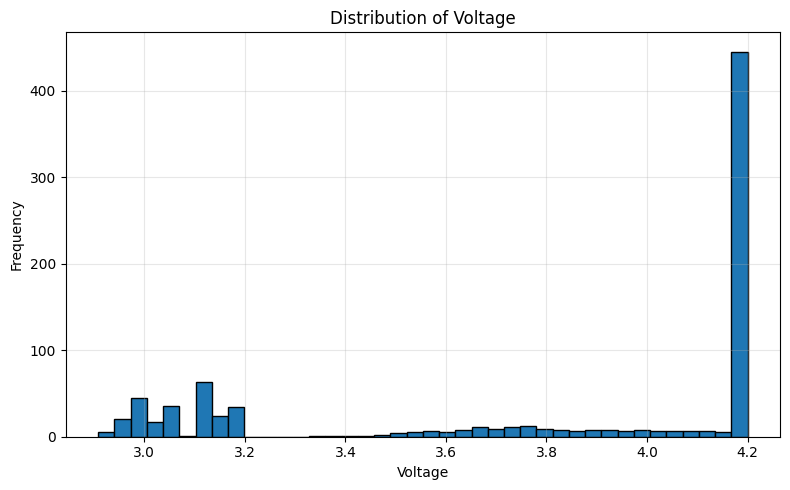

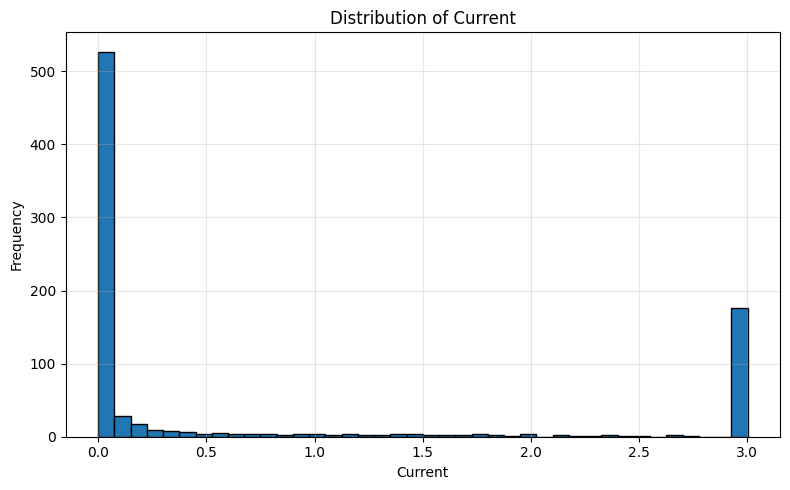

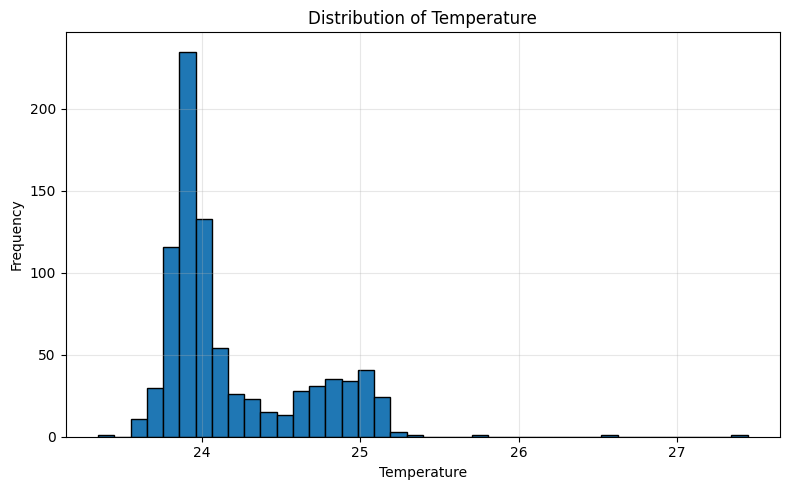

In [ ]:
print("Generating distribution plots.")
for col in analysis_columns:
    data = battery_df[col].dropna()
    if len(data) == 0:
        continue
    plt.figure(figsize=(8, 5))
    plt.hist(data,bins=40,edgecolor='black')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

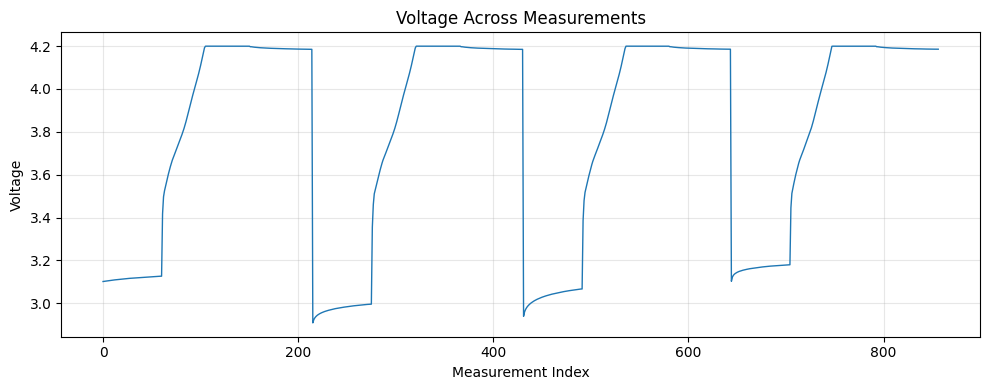

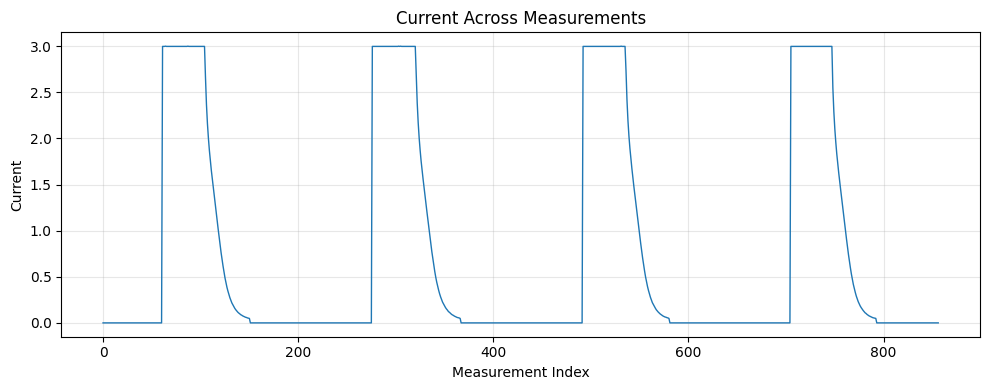

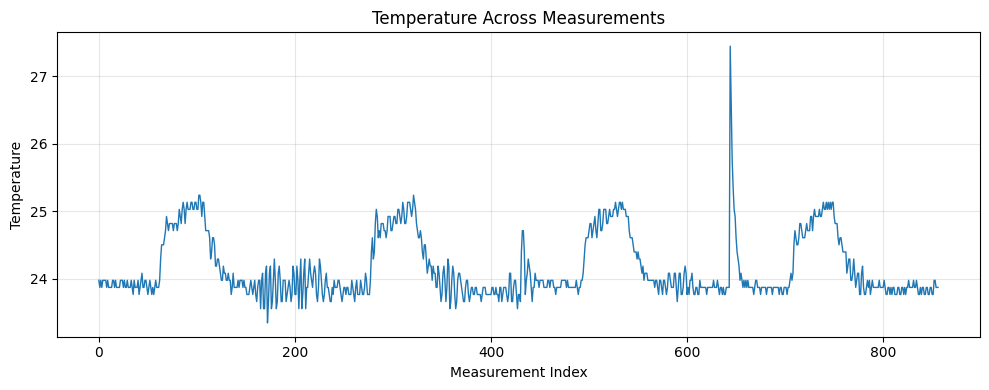

In [ ]:
for col in analysis_columns:
    data = battery_df[[col]].dropna()
    if len(data) == 0:
        continue
    plt.figure(figsize=(10, 4))
    plt.plot(data[col].values,linewidth=1)
    plt.xlabel("Measurement Index")
    plt.ylabel(col)
    plt.title(f"{col} Across Measurements")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
print("CHECKING DATA FOR SOC AND REMAINING CHARGING TIME")
print("\nFirst 15 rows:")
display(battery_df[['Time Stamp','Step','Status','Prog Time','Step Time','Cycle','Voltage','Current','Temperature','Capacity','WhAccu']].head(15))
print("\nStatus values:")
print(battery_df['Status'].value_counts(dropna=False))
print("\nProcedure values:")
print(battery_df['Procedure'].value_counts(dropna=False).head(20))
print("\nData types:")
print(battery_df[['Time Stamp','Status','Prog Time','Step Time','Cycle','Voltage','Current','Temperature','Capacity','WhAccu']].dtypes)

CHECKING DATA FOR SOC AND REMAINING CHARGING TIME

First 15 rows:


,Time Stamp,Step,Status,Prog Time,Step Time,Cycle,Voltage,Current,Temperature,Capacity,WhAccu
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[Ah],[Wh]
1,NaN,4.0,PAU,01:00.0,01:00.0,0.0,3.10125,0.0,23.97615,0,0
2,NaN,4.0,PAU,02:00.0,02:00.0,0.0,3.10192,0.0,23.87099,0,0
3,NaN,4.0,PAU,03:00.0,03:00.0,0.0,3.10260,0.0,23.97615,0,0
4,NaN,4.0,PAU,04:00.0,04:00.0,0.0,3.10344,0.0,23.87099,0,0
5,NaN,4.0,PAU,05:00.0,05:00.0,0.0,3.10412,0.0,23.97615,0,0
6,NaN,4.0,PAU,06:00.0,06:00.0,0.0,3.10462,0.0,23.97615,0,0
7,NaN,4.0,PAU,07:00.0,07:00.0,0.0,3.10530,0.0,23.97615,0,0
8,NaN,4.0,PAU,08:00.0,08:00.0,0.0,3.10597,0.0,23.97615,0,0
9,NaN,4.0,PAU,09:00.0,09:00.0,0.0,3.10648,0.0,23.87099,0,0



Status values:
Status
PAU    498
CHA    358
NaN      1
STO      1
Name: count, dtype: int64

Procedure values:
Procedure
NN_Char_Charge    854
LG_HG2_NN_Char      3
NaN                 1
Name: count, dtype: int64

Data types:
Time Stamp     float64
Status          object
Prog Time       object
Step Time       object
Cycle          float64
Voltage        float64
Current        float64
Temperature    float64
Capacity        object
WhAccu          object
dtype: object


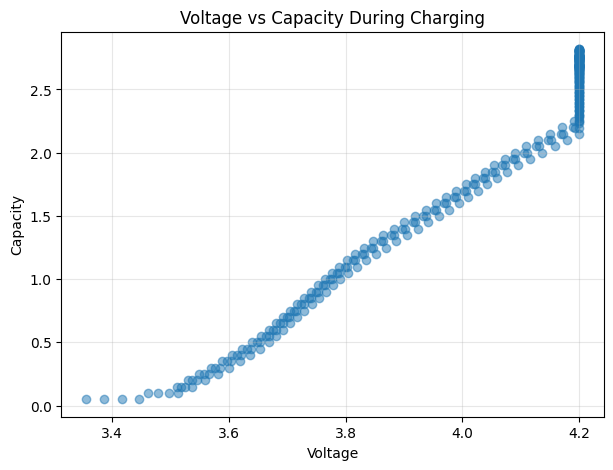

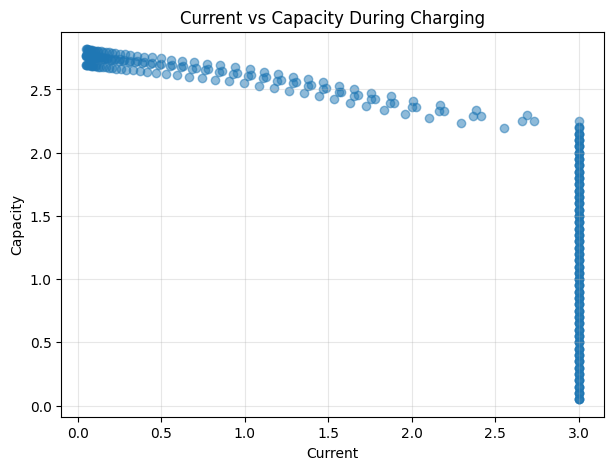

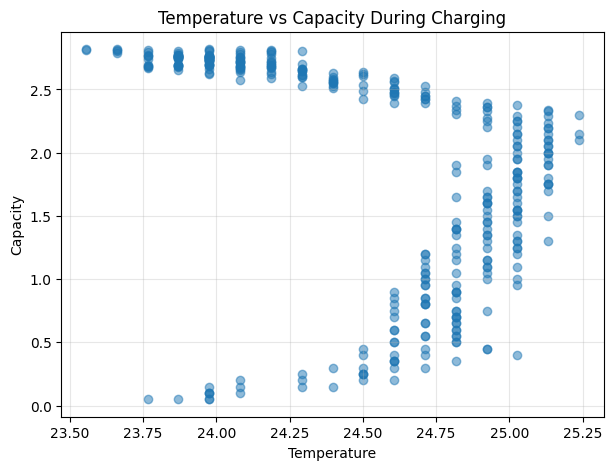

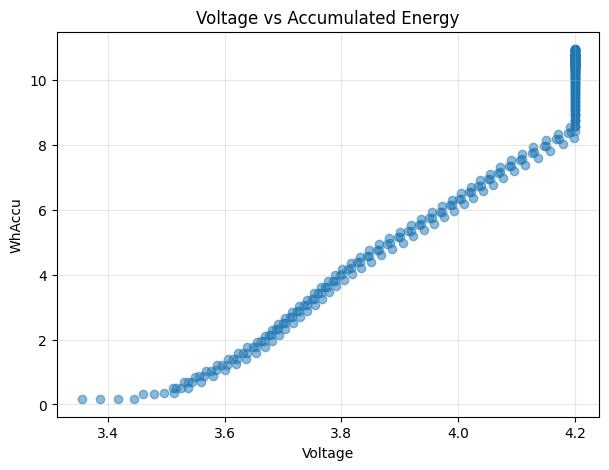

In [ ]:
charging_df = battery_df[battery_df["Status"] == "CHA"].copy()
charging_df["Voltage"] = pd.to_numeric(charging_df["Voltage"], errors="coerce")
charging_df["Current"] = pd.to_numeric(charging_df["Current"], errors="coerce")
charging_df["Temperature"] = pd.to_numeric(charging_df["Temperature"], errors="coerce")
charging_df["Capacity"] = pd.to_numeric(charging_df["Capacity"], errors="coerce")
charging_df["WhAccu"] = pd.to_numeric(charging_df["WhAccu"], errors="coerce")

#Voltage vs Capacity
plt.figure(figsize=(7, 5))
plt.scatter(charging_df["Voltage"],charging_df["Capacity"],alpha=0.5)
plt.xlabel("Voltage")
plt.ylabel("Capacity")
plt.title("Voltage vs Capacity During Charging")
plt.grid(alpha=0.3)
plt.show()

# Current vs Capacity
plt.figure(figsize=(7, 5))
plt.scatter(charging_df["Current"],charging_df["Capacity"],alpha=0.5)
plt.xlabel("Current")
plt.ylabel("Capacity")
plt.title("Current vs Capacity During Charging")
plt.grid(alpha=0.3)
plt.show()
# Temperature vs Capacity
plt.figure(figsize=(7, 5))
plt.scatter(charging_df["Temperature"],charging_df["Capacity"],alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Capacity")
plt.title("Temperature vs Capacity During Charging")
plt.grid(alpha=0.3)
plt.show()

# Voltage vs Energy
plt.figure(figsize=(7, 5))
plt.scatter(charging_df["Voltage"],charging_df["WhAccu"],alpha=0.5)
plt.xlabel("Voltage")
plt.ylabel("WhAccu")
plt.title("Voltage vs Accumulated Energy")
plt.grid(alpha=0.3)
plt.show()

CORRELATION MATRIX


,Time Stamp,Step,Cycle,Cycle Level,Voltage,Current,Temperature
Time Stamp,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Step,NaN,1.000,NaN,NaN,0.032,-0.024,-0.023
Cycle,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cycle Level,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Voltage,NaN,0.032,NaN,NaN,1.000,0.130,0.104
Current,NaN,-0.024,NaN,NaN,0.130,1.000,0.821
Temperature,NaN,-0.023,NaN,NaN,0.104,0.821,1.000


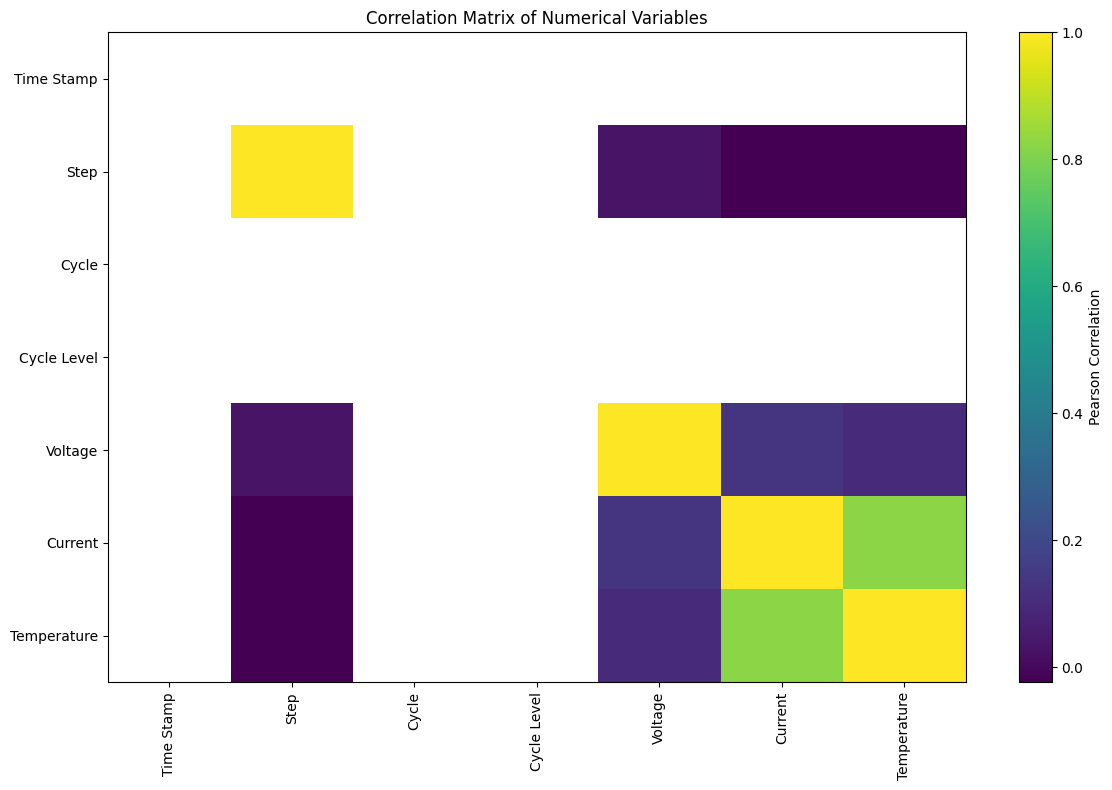


Correlation analysis completed successfully.


In [ ]:
numeric_df = battery_df.select_dtypes(
    include=[np.number])
if numeric_df.shape[1] == 0:
    print("No numerical columns were found.")
    print("Correlation analysis cannot be performed.")
else:
    correlation_matrix = numeric_df.corr(method='pearson')
    print("CORRELATION MATRIX")
    display(correlation_matrix.round(3))
    # Plot correlation matrix
    plt.figure(figsize=(12, 8))
    plt.imshow(correlation_matrix,interpolation='nearest',aspect='auto')
    plt.colorbar(label='Pearson Correlation')
    plt.xticks(range(len(correlation_matrix.columns)),correlation_matrix.columns,rotation=90)
    plt.yticks(range(len(correlation_matrix.columns)),correlation_matrix.columns)
    plt.title("Correlation Matrix of Numerical Variables")
    plt.tight_layout()
    plt.show()
    print("\nCorrelation analysis completed successfully.")

In [ ]:
if "SOC" in battery_df.columns:
    print("\nSOC target is available.")
    print(battery_df[["Voltage", "Current", "Temperature", "SOC"]].corr()["SOC"].round(2))
else:
    print("\nSOC column is not present in the dataset.")
if "Remaining Charging Time" in battery_df.columns:
    print("\nRemaining Charging Time target is available.")
    print(battery_df[["Voltage","Current","Temperature","Remaining Charging Time"]].corr()["Remaining Charging Time"].round(2))
else:
    print("\nRemaining Charging Time column is not present.")
print("\nDirect input-target correlation could not be")
print("calculated because the target columns are not")
print("available in the current dataset.")



SOC column is not present in the dataset.

Remaining Charging Time column is not present.

Direct input-target correlation could not be
calculated because the target columns are not
available in the current dataset.


 NONLINEAR RELATIONSHIPS


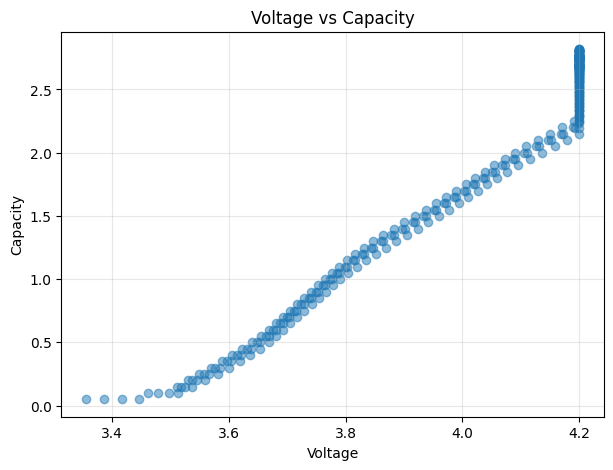

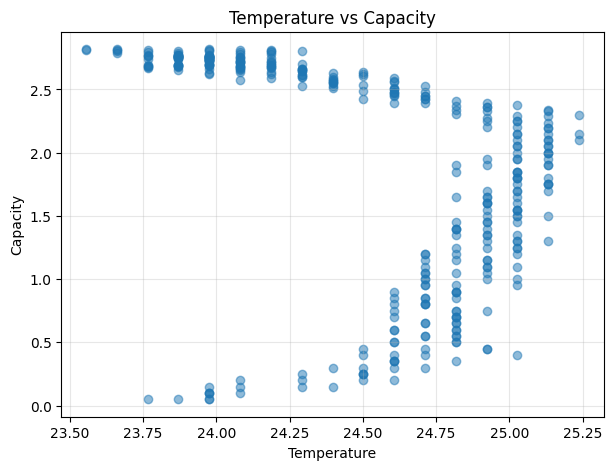


The scatter plots were used to check whether
the relationships appear linear or nonlinear.


In [ ]:
print(" NONLINEAR RELATIONSHIPS")
charging_df = battery_df[battery_df["Status"] == "CHA"].copy()
charging_df["Voltage"] = pd.to_numeric(
charging_df["Voltage"], errors="coerce")
charging_df["Temperature"] = pd.to_numeric(charging_df["Temperature"], errors="coerce")
charging_df["Capacity"] = pd.to_numeric(charging_df["Capacity"], errors="coerce")


# Voltage and Capacity
plt.figure(figsize=(7, 5))
plt.scatter(charging_df["Voltage"],charging_df["Capacity"],alpha=0.5)
plt.xlabel("Voltage")
plt.ylabel("Capacity")
plt.title("Voltage vs Capacity")
plt.grid(alpha=0.3)
plt.show()

# Temperature and Capacity
plt.figure(figsize=(7, 5))
plt.scatter(charging_df["Temperature"],charging_df["Capacity"],alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Capacity")
plt.title("Temperature vs Capacity")
plt.grid(alpha=0.3)
plt.show()
print("\nThe scatter plots were used to check whether")
print("the relationships appear linear or nonlinear.")

OPERATING REGIONS


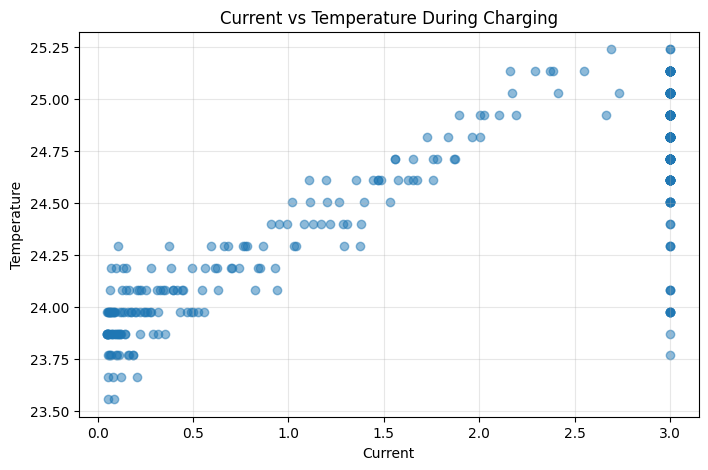


The graph shows the operating regions of
current and temperature during charging.


In [ ]:
print("OPERATING REGIONS")
charging_df = battery_df[battery_df["Status"] == "CHA"].copy()
charging_df["Current"] = pd.to_numeric(charging_df["Current"], errors="coerce")
charging_df["Temperature"] = pd.to_numeric(charging_df["Temperature"], errors="coerce")
plt.figure(figsize=(8, 5))
plt.scatter(charging_df["Current"],charging_df["Temperature"],alpha=0.5)
plt.xlabel("Current")
plt.ylabel("Temperature")
plt.title("Current vs Temperature During Charging")
plt.grid(alpha=0.3)
plt.show()
print("\nThe graph shows the operating regions of")
print("current and temperature during charging.")

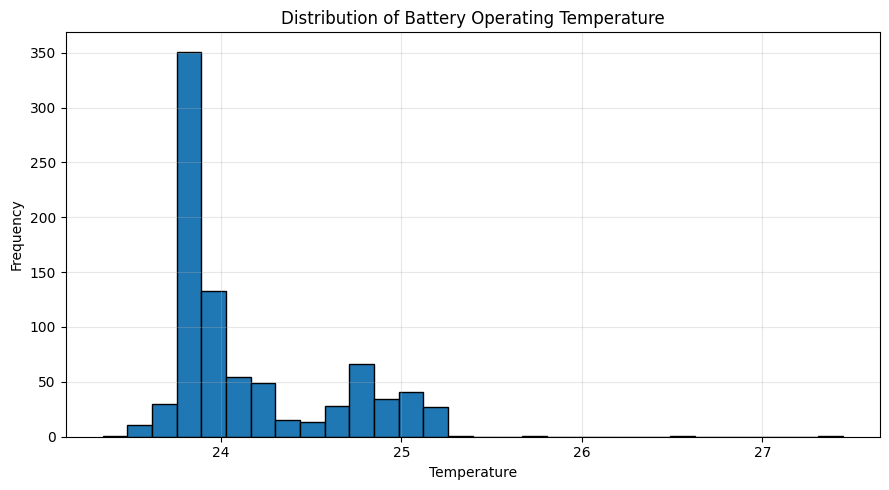


Temperature statistics:
count    857.000
mean      24.156
std        0.465
min       23.345
25%       23.871
50%       23.976
75%       24.397
max       27.446
Name: Temperature, dtype: float64


In [ ]:
if temperature_col is not None:
    temp_data = battery_df[temperature_col].dropna()
    if len(temp_data) > 0:
        plt.figure(figsize=(9, 5))
        plt.hist(temp_data,bins=30,edgecolor='black')
        plt.xlabel(temperature_col)
        plt.ylabel("Frequency")
        plt.title("Distribution of Battery Operating Temperature")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
        print("\nTemperature statistics:")
        print(temp_data.describe().round(3))
else:
    print("Temperature column was not found.")

In [ ]:
print("DATA LEAKAGE CHECK")
target_variables = ["SOC","Remaining Charging Time"]
for target in target_variables:
    if target in battery_df.columns:
        print("\nChecking target:", target)
        for col in battery_df.columns:
            if col == target:
                continue
            if "soc" in str(col).lower() and "soc" in target.lower():
                print("Possible leakage column:", col)
            elif "remaining" in str(target).lower() and "remaining" in str(col).lower():
                print("Possible leakage column:", col)
        print("Leakage check completed.")
    else:
        print("\nTarget not found in dataset:", target)
print("\nInput and Target Overlap Check")
input_variables = [
    col for col in battery_df.columns
    if col not in target_variables]
overlap = set(input_variables).intersection(set(target_variables))
if len(overlap) == 0:
    print("No input-target overlap found.")
else:
    print("WARNING: Overlapping columns found:")
    print(overlap)

DATA LEAKAGE CHECK

Target not found in dataset: SOC

Target not found in dataset: Remaining Charging Time

Input and Target Overlap Check
No input-target overlap found.


In [ ]:
duplicate_count = battery_df.duplicated().sum()
duplicate_percentage = (duplicate_count/ len(battery_df)* 100)
print("DUPLICATE ROW CHECK")
print("Duplicate rows:",duplicate_count)
print(
    f"Duplicate percentage: "
    f"{duplicate_percentage:.2f}%")

DUPLICATE ROW CHECK
Duplicate rows: 12
Duplicate percentage: 1.40%


In [ ]:
print(" DUPLICATE RECORDS")
duplicate_rows = battery_df.duplicated().sum()
print("\nDuplicate rows found:", duplicate_rows)
battery_df = battery_df.drop_duplicates()
print("Duplicate rows removed.")
print("\nRows after removing duplicates:", len(battery_df))

 DUPLICATE RECORDS

Duplicate rows found: 12
Duplicate rows removed.

Rows after removing duplicates: 846


In [ ]:
print(" BASIC EDA FINDINGS")
print("\nBasic statistics:")
print(battery_df[["Voltage", "Current", "Temperature", "Capacity", "WhAccu"]].describe())
print("\nMinimum values:")
print(battery_df[["Voltage", "Current", "Temperature", "Capacity", "WhAccu"]].min())
print("\nMaximum values:")
print(battery_df[["Voltage", "Current", "Temperature", "Capacity", "WhAccu"]].max())
print("\nNumber of charging records:")
charging_records = battery_df[battery_df["Status"] == "CHA"]
print(len(charging_records))
print("\nBattery status values:")
print(battery_df["Status"].value_counts())

 BASIC EDA FINDINGS

Basic statistics:
          Voltage     Current  Temperature
count  845.000000  845.000000   845.000000
mean     3.798611    0.777509    24.159459
std      0.489803    1.221568     0.467085
min      2.908080    0.000000    23.345190
25%      3.168840    0.000000    23.870990
50%      4.185630    0.000000    23.976150
75%      4.193550    1.443070    24.501940
max      4.199950    3.001080    27.446380

Minimum values:
Voltage         2.90808
Current             0.0
Temperature    23.34519
Capacity              0
WhAccu                0
dtype: object

Maximum values:
Voltage         4.19995
Current         3.00108
Temperature    27.44638
Capacity           [Ah]
WhAccu             [Wh]
dtype: object

Number of charging records:
358

Battery status values:
Status
PAU    486
CHA    358
STO      1
Name: count, dtype: int64


In [ ]:
print("SAVING EDA RESULTS")
battery_df.to_csv("/content/cleaned_battery_data.csv",index=False)
numeric_data = battery_df.select_dtypes(
    include="number")
correlation = numeric_data.corr()
correlation.to_csv("/content/correlation_results.csv")
print("\nCleaned battery data saved successfully.")
print("Correlation results saved successfully.")


SAVING EDA RESULTS

Cleaned battery data saved successfully.
Correlation results saved successfully.
